# Inspect Training Data Pipeline

这个 notebook 用来检查两层数据：

- 数据集本身：HDF5 / `station_metadata`
- 输入到模型前的 generator 输出：裁窗、pick、mask、PGA target

当前训练链路里，事件级裁窗是统一对整个事件做一次，所有台站共享同一个 `crop_start`，因此台站间时间仍然对齐。

In [1]:
from pathlib import Path
import copy
import json
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path('/home/zhangb/work/people/zhangbei/team_claude/team_pytorch')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import loader_light as loader
import gemini_util_light as util

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

In [14]:
# 修改这里
CONFIG_PATH = ROOT / 'pga_configs' / 'transformer_japan_overfit.json'
SPLIT = 'train'   # 'train' / 'dev'
DATASET_INDEX = 0
SAMPLE_INDEX = 1733
EVENT_ID = None   # 例如 '20240101123400'；None 表示按 SAMPLE_INDEX 取
OVERFIT_N = 0
MIN_STALTA_RATIO = 0.1
data_path = '/tmp/japan_build_test3/japan_2024.hdf5'

In [15]:
config = json.loads(CONFIG_PATH.read_text())
config['training_params']['data_path'] = data_path
training_params = copy.deepcopy(config['training_params'])
generator_params = copy.deepcopy(training_params.get('generator_params', [training_params.copy()]))
if not isinstance(training_params['data_path'], list):
    training_params['data_path'] = [training_params['data_path']]

part_map = {'train': (True, False, False), 'dev': (False, True, False)}
cache_name = 'inspect_train_ev.csv' if SPLIT == 'train' else 'inspect_dev_ev.csv'
parts = part_map[SPLIT]
overwrite_sampling_rate = training_params.get('overwrite_sampling_rate', None)

data_path = Path(training_params['data_path'][DATASET_INDEX])
if not data_path.is_absolute():
    data_path = (ROOT / data_path).resolve()
generator_param = generator_params[DATASET_INDEX]
event_metadata, _, metadata = loader.load_events(
    str(data_path),
    event_metadata_path=str(ROOT / cache_name),
    parts=parts,
    shuffle_train_dev=generator_param.get('shuffle_train_dev', False),
    custom_split=generator_param.get('custom_split', None),
    min_mag=generator_param.get('min_mag', None),
    mag_key=generator_param.get('key', 'MA'),
    overwrite_sampling_rate=overwrite_sampling_rate,
    decimate_events=generator_param.get('decimate_events', None),
    min_stalta_ratio_at_pick=MIN_STALTA_RATIO,
)

event_key = loader.detect_event_key(event_metadata.columns)
resolved_mag_key = metadata.get('resolved_mag_key', generator_param.get('key', 'MA'))
sampling_rate = metadata['sampling_rate']

print('data_path          =', data_path)
print('split              =', SPLIT)
print('rows               =', len(event_metadata))
print('events             =', event_metadata[event_key].nunique())
print('sampling_rate      =', sampling_rate)
print('resolved_mag_key   =', resolved_mag_key)
print('min_stalta_ratio   =', metadata.get('min_stalta_ratio_at_pick'))

Using station metadata cache /home/zhangb/work/people/zhangbei/team_claude/team_pytorch/station_cache_be3d3057.csv
data_path          = /tmp/japan_build_test3/japan_2024.hdf5
split              = train
rows               = 31094
events             = 687
sampling_rate      = 100.0
resolved_mag_key   = Magnitude
min_stalta_ratio   = 0.1


In [16]:
summary_cols = [c for c in [event_key, resolved_mag_key, 'Latitude', 'Longitude', 'DEPTH', 'wave_idx', 'p_pick_refined_aligned', 'p_pick_trigger_aligned', 'stalta_ratio_at_pick', 'source_network', 'sensor_class'] if c in event_metadata.columns]
display(event_metadata[summary_cols].head(10))
display(event_metadata[[resolved_mag_key, 'stalta_ratio_at_pick']].describe())

,EVENT,Magnitude,Latitude,Longitude,DEPTH,wave_idx,p_pick_refined_aligned,p_pick_trigger_aligned,stalta_ratio_at_pick,source_network,sensor_class
0,20240101160600,5.5,37.51,137.245,12.0,0,5700,6100,1.446174,knt,single_surface
1,20240101160600,5.5,37.51,137.245,12.0,1,5500,6900,1.259959,knt,single_surface
2,20240101160600,5.5,37.51,137.245,12.0,2,5100,6500,1.021286,knt,single_surface
3,20240101160600,5.5,37.51,137.245,12.0,3,5816,7200,0.885218,knt,single_surface
4,20240101160600,5.5,37.51,137.245,12.0,4,6600,8000,0.707115,knt,single_surface
5,20240101160600,5.5,37.51,137.245,12.0,5,7300,8700,0.357350,knt,single_surface
6,20240101160600,5.5,37.51,137.245,12.0,6,6400,6800,0.477822,knt,single_surface
7,20240101160600,5.5,37.51,137.245,12.0,7,6000,6400,0.780279,knt,single_surface
8,20240101160600,5.5,37.51,137.245,12.0,8,5400,6800,0.933847,knt,single_surface
9,20240101160600,5.5,37.51,137.245,12.0,9,3900,5300,0.954804,knt,single_surface


,Magnitude,stalta_ratio_at_pick
count,31094.000000,31094.000000
mean,4.764906,0.530110
std,1.047029,0.386545
min,3.000000,0.100083
25%,4.000000,0.214861
50%,4.600000,0.327084
75%,5.300000,0.817328
max,7.600000,2.661492


In [17]:
event_metadata.copy().drop_duplicates('EVENT')

,DEPTH,EVENT,Latitude,Longitude,Magnitude,Origin_Time(JST),archive_relpath,component_base,duration_header_s,event_length_samples,...,stalta_search_right_aligned,station_code,station_height_m,station_lat,station_lon,trigger_is_pick,trigger_time_jst,trigger_to_pga_seconds,valid_n_samples,wave_idx
0,12.0,20240101160600,37.510,137.245,5.5,2024/01/01 16:06:00,2024/20240101160600.tar,FKI0012401011606,64.0,22400,...,6200,FKI001,3.0,36.2193,136.1565,True,2024-01-01T16:06:54+09:00,3.59,6400,0
222,16.0,20240101161000,37.495,137.270,7.6,2024/01/01 16:10:00,2024/20240101161000.tar,AIC0012401011610,208.0,51400,...,17400,AIC001,5.0,35.2974,136.7505,True,2024-01-01T16:11:05+09:00,46.36,20800,0
1733,12.0,20240101161700,37.318,136.943,5.1,2024/01/01 16:17:00,2024/20240101161700.tar,FKS0222401011617,60.0,42000,...,23100,FKS022,159.0,37.6005,139.6472,False,2024-01-01T16:17:58+09:00,0.34,6000,0
1822,11.0,20240101161800,37.198,136.818,6.1,2024/01/01 16:18:00,2024/20240101161800.tar,AIC0012401011618,60.0,53200,...,29800,AIC001,5.0,35.2974,136.7505,False,2024-01-01T16:19:46+09:00,0.63,6000,0
2263,7.0,20240101162000,37.195,136.880,4.1,2024/01/01 16:20:00,2024/20240101162000.tar,FKS0282401011620,60.0,32700,...,5537,FKS028,416.0,37.3037,139.3619,False,2024-01-01T16:20:28+09:00,0.87,6000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30860,46.0,20240503091000,33.807,135.352,3.8,2024/05/03 09:10:00,2024/20240503091000.tar,MIE0082405030910,60.0,14000,...,2836,MIE008,222.0,34.6291,136.1074,False,2024-05-03T09:10:55+09:00,0.54,6000,0
30913,37.0,20240503135200,33.192,132.385,3.2,2024/05/03 13:52:00,2024/20240503135200.tar,EHM0112405031352,60.0,12900,...,1358,EHM011,8.0,33.4498,132.4341,False,2024-05-03T13:52:34+09:00,0.28,6000,0
30934,38.0,20240504094000,33.230,132.373,3.9,2024/05/04 09:40:00,2024/20240504094000.tar,EHM0052405040940,60.0,16100,...,2400,EHM005,136.0,33.7973,132.9144,False,2024-05-04T09:40:34+09:00,1.17,6000,0
31010,37.0,20240506005000,33.155,132.410,3.9,2024/05/06 00:50:00,2024/20240506005000.tar,EHM0052405060050,60.0,15000,...,2927,EHM005,136.0,33.7973,132.9144,False,2024-05-06T00:50:27+09:00,0.55,6000,0


In [18]:
if EVENT_ID is None:
    sample_row = event_metadata.iloc[SAMPLE_INDEX]
    EVENT_ID = str(sample_row[event_key])
else:
    EVENT_ID = str(EVENT_ID)

event_rows = event_metadata[event_metadata[event_key].astype(str) == EVENT_ID].copy().sort_values('wave_idx').reset_index(drop=True)
print('EVENT_ID =', EVENT_ID)
print('n_rows   =', len(event_rows))
display(event_rows[summary_cols].head(20))

EVENT_ID = 20240101161700
n_rows   = 89


,EVENT,Magnitude,Latitude,Longitude,DEPTH,wave_idx,p_pick_refined_aligned,p_pick_trigger_aligned,stalta_ratio_at_pick,source_network,sensor_class
0,20240101161700,5.1,37.318,136.943,12.0,0,23100,24500,0.616835,knt,single_surface
1,20240101161700,5.1,37.318,136.943,12.0,1,24800,25200,1.388821,knt,single_surface
2,20240101161700,5.1,37.318,136.943,12.0,2,22800,24200,0.648627,knt,single_surface
3,20240101161700,5.1,37.318,136.943,12.0,3,22700,24100,0.821908,knt,single_surface
4,20240101161700,5.1,37.318,136.943,12.0,4,22900,24300,1.196349,knt,single_surface
5,20240101161700,5.1,37.318,136.943,12.0,5,20600,22000,1.067908,knt,single_surface
6,20240101161700,5.1,37.318,136.943,12.0,6,20800,22200,1.001516,knt,single_surface
7,20240101161700,5.1,37.318,136.943,12.0,7,21100,22500,1.015705,knt,single_surface
8,20240101161700,5.1,37.318,136.943,12.0,8,22700,24100,1.066729,knt,single_surface
9,20240101161700,5.1,37.318,136.943,12.0,9,26600,28000,0.710932,knt,single_surface


In [19]:
with h5py.File(data_path, 'r') as f:
    g = f['data'][EVENT_ID]
    wave_idx = event_rows['wave_idx'].to_numpy(dtype=int)
    waveforms = g['waveforms'][wave_idx]
    picks = g['p_picks'][wave_idx].astype(int)
    trigger_picks = g['p_pick_trigger_aligned'][wave_idx].astype(int) if 'p_pick_trigger_aligned' in g else picks.copy()
    refined_picks = g['p_pick_refined_aligned'][wave_idx].astype(int) if 'p_pick_refined_aligned' in g else picks.copy()
    ratio_at_pick = g['stalta_ratio_at_pick'][wave_idx] if 'stalta_ratio_at_pick' in g else np.full(len(wave_idx), np.nan)
    pga = g['pga'][wave_idx] if 'pga' in g else None

print('aligned event waveforms shape =', waveforms.shape)
print('p_picks range                =', int(refined_picks.min()), int(refined_picks.max()))
if pga is not None:
    print('pga looks logged?            =', bool(np.nanmax(pga) < 5 and np.nanmin(pga) > -20))

aligned event waveforms shape = (89, 42000, 3)
p_picks range                = 1100 31100
pga looks logged?            = True


In [20]:
# 事件级统一裁窗检查：所有台站共用同一个 crop_start
noise_seconds = generator_param.get('noise_seconds', 5)
cropped_waveforms, shifted_picks, crop_start = util._crop_aligned_event_window(
    waveforms.copy(),
    refined_picks.copy(),
    10000,
    sampling_rate,
    noise_seconds,
)
print('crop_start =', crop_start)
print('cropped shape =', cropped_waveforms.shape)
print('shifted pick min/max =', int(shifted_picks.min()), int(shifted_picks.max()))
assert np.all(shifted_picks == refined_picks - crop_start)
print('所有台站 pick 都统一减去了同一个 crop_start。')

crop_start = 10600
cropped shape = (89, 10000, 3)
shifted pick min/max = -9500 20500
所有台站 pick 都统一减去了同一个 crop_start。


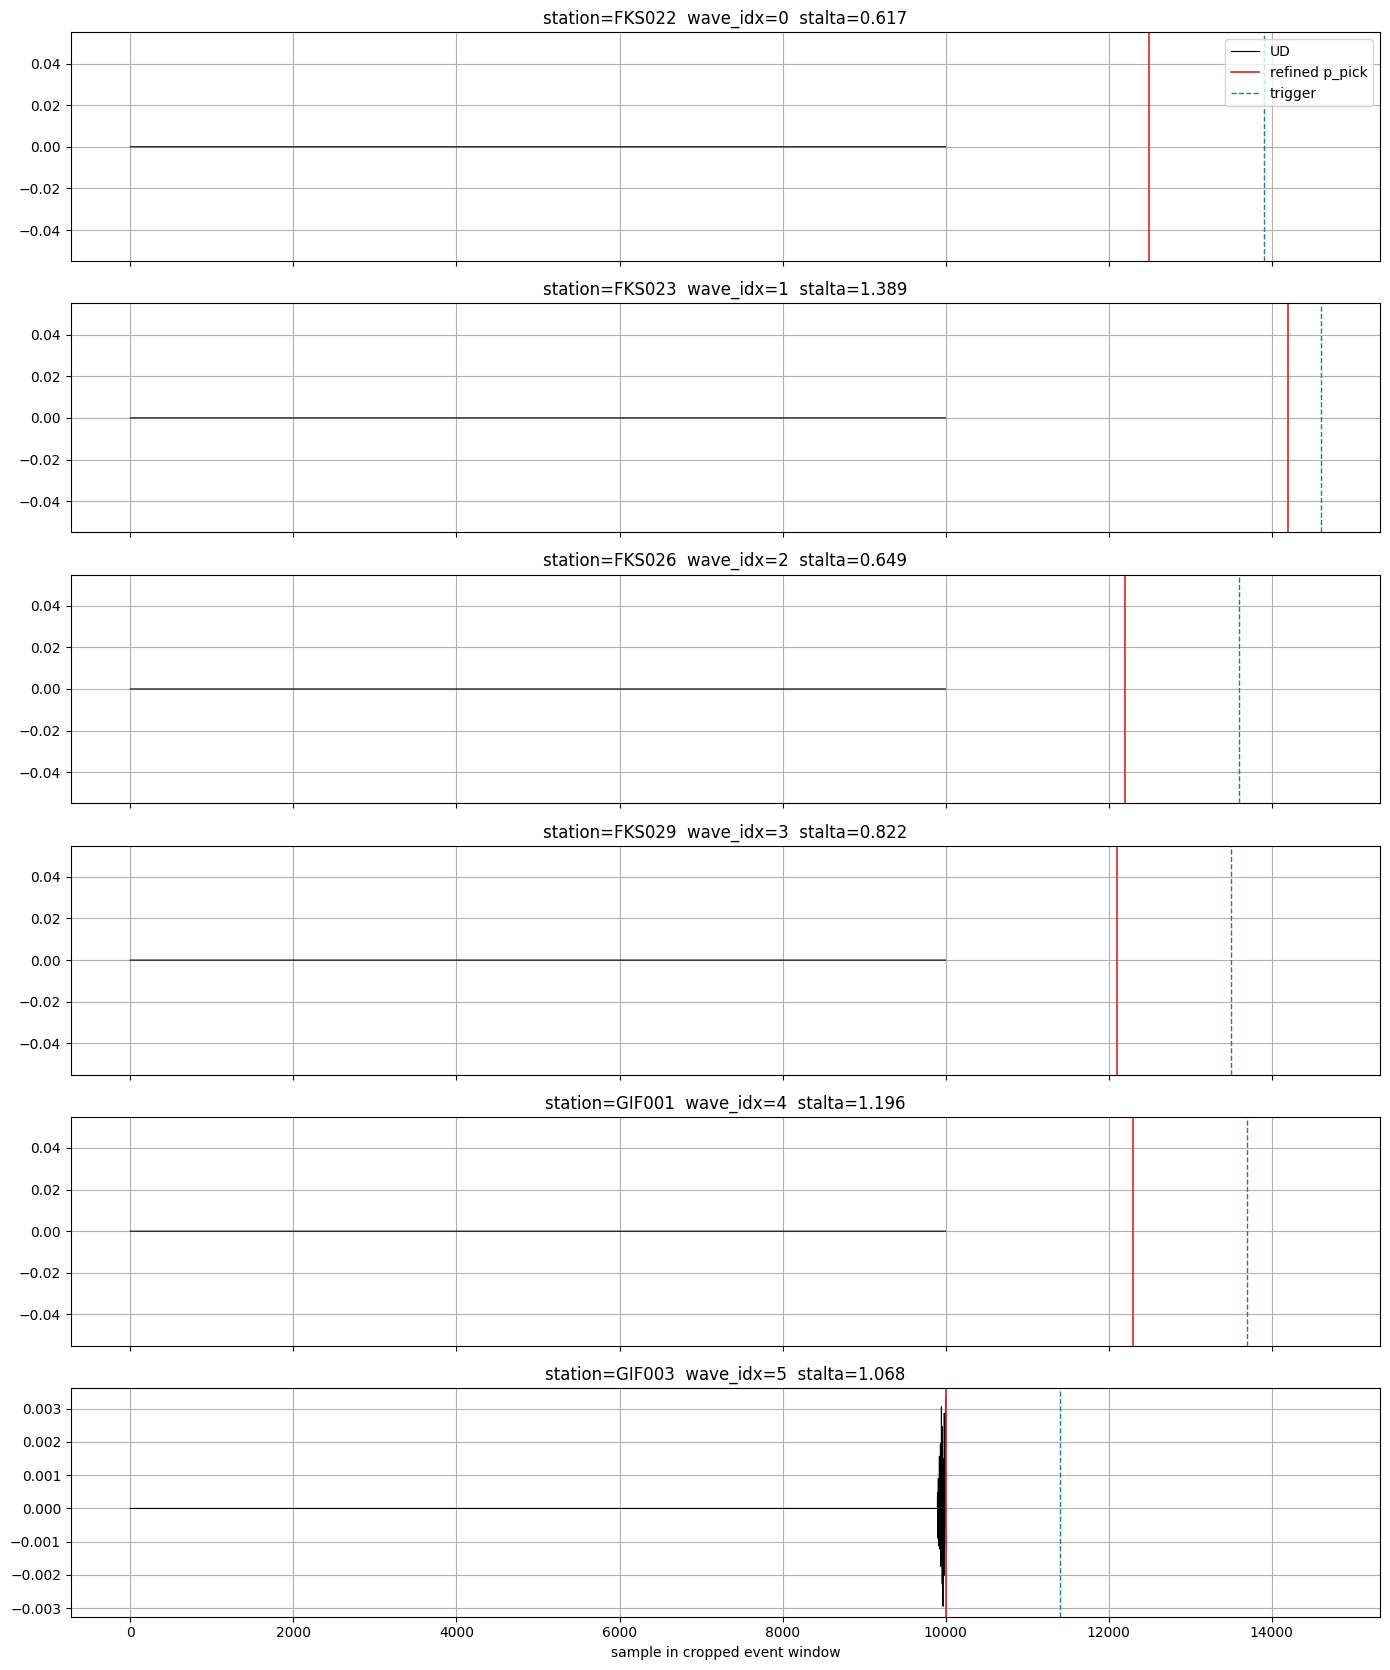

In [21]:
stations_to_plot = min(6, len(event_rows))
fig, axes = plt.subplots(stations_to_plot, 1, figsize=(14, 2.8 * stations_to_plot), sharex=True)
if stations_to_plot == 1:
    axes = [axes]

for i in range(stations_to_plot):
    ax = axes[i]
    ax.plot(cropped_waveforms[i, :, 2], lw=0.8, color='black', label='UD')
    ax.axvline(shifted_picks[i], color='tab:red', lw=1.2, label='refined p_pick')
    ax.axvline(trigger_picks[i] - crop_start, color='tab:blue', lw=1.0, linestyle='--', label='trigger')
    ax.set_title(f"station={event_rows.iloc[i]['station_code']}  wave_idx={int(event_rows.iloc[i]['wave_idx'])}  stalta={event_rows.iloc[i]['stalta_ratio_at_pick']:.3f}")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:3], labels[:3], loc='upper right')
axes[-1].set_xlabel('sample in cropped event window')
plt.tight_layout()
plt.show()
plt.close('all')

In [22]:
# 构造与训练一致的 generator，并查看真正送入模型前的数据
generator_param_inspect = copy.deepcopy(generator_param)
max_stations = config['model_params']['max_stations']
n_pga_targets = config['model_params'].get('n_pga_targets', 0)
no_event_token = config['model_params'].get('no_event_token', False)
cutout = (
    sampling_rate * (noise_seconds + generator_param_inspect['cutout_start']),
    sampling_rate * (noise_seconds + generator_param_inspect['cutout_end']),
)
merged = {
    'coords_target': True,
    'label_smoothing': False,
    'station_blinding': False,
    'cutout': cutout,
    'pga_targets': n_pga_targets,
    'max_stations': max_stations,
    'sampling_rate': sampling_rate,
    'no_event_token': no_event_token,
    **generator_param_inspect,
}
dataset = util.PreloadedEventGenerator(
    event_metadata=event_metadata,
    metadata=copy.deepcopy(metadata),
    data_path=str(data_path),
    generator_params=generator_param_inspect,
    **merged,
)

dataset_event_idx = dataset.event_keys.index(int(EVENT_ID))
sample_pos = int(np.where(dataset.indexes == dataset_event_idx)[0][0])
inputs, outputs, p_pick_info = dataset[sample_pos]

print('waveforms shape   =', tuple(inputs[0].shape))
print('metadata shape    =', tuple(inputs[1].shape))
print('valid stations    =', int(inputs[2].sum().item()))
print('label tensors     =', [tuple(x.shape) for x in outputs])
print('p_pick_info keys  =', list(p_pick_info.keys()))

Unused parameters: batch_size, translate, shuffle_train_dev, noise_seconds, cutout_start, cutout_end
waveforms shape   = (25, 3, 10000)
metadata shape    = (25, 3)
valid stations    = 21
label tensors     = [(1,), (3,), (15, 1)]
p_pick_info keys  = ['shifted', 'raw', 'shift']


In [23]:
inputs[4]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True])

In [24]:
wave_in = inputs[0].numpy()          # (S, C, T)
coords_in = inputs[1].numpy()
station_valid = inputs[2].numpy().astype(bool)
p_pick_raw = p_pick_info['raw'].numpy()
p_pick_shifted = p_pick_info['shifted'].numpy()
shift = float(p_pick_info['shift'].item())

valid_idx = np.where(station_valid)[0]
print('generator shift =', shift)
display(pd.DataFrame({
    'slot': np.arange(len(station_valid)),
    'station_valid': station_valid,
    'p_pick_raw': p_pick_raw,
    'p_pick_shifted': p_pick_shifted,
}).head(20))

generator shift = 8131.0


,slot,station_valid,p_pick_raw,p_pick_shifted
0,0,False,3800.0,11931.0
1,1,True,700.0,8831.0
2,2,True,1100.0,9231.0
3,3,True,200.0,8331.0
4,4,True,1100.0,9231.0
5,5,True,1600.0,9731.0
6,6,False,3800.0,11931.0
7,7,True,-6700.0,1431.0
8,8,True,-700.0,7431.0
9,9,True,-5400.0,2731.0


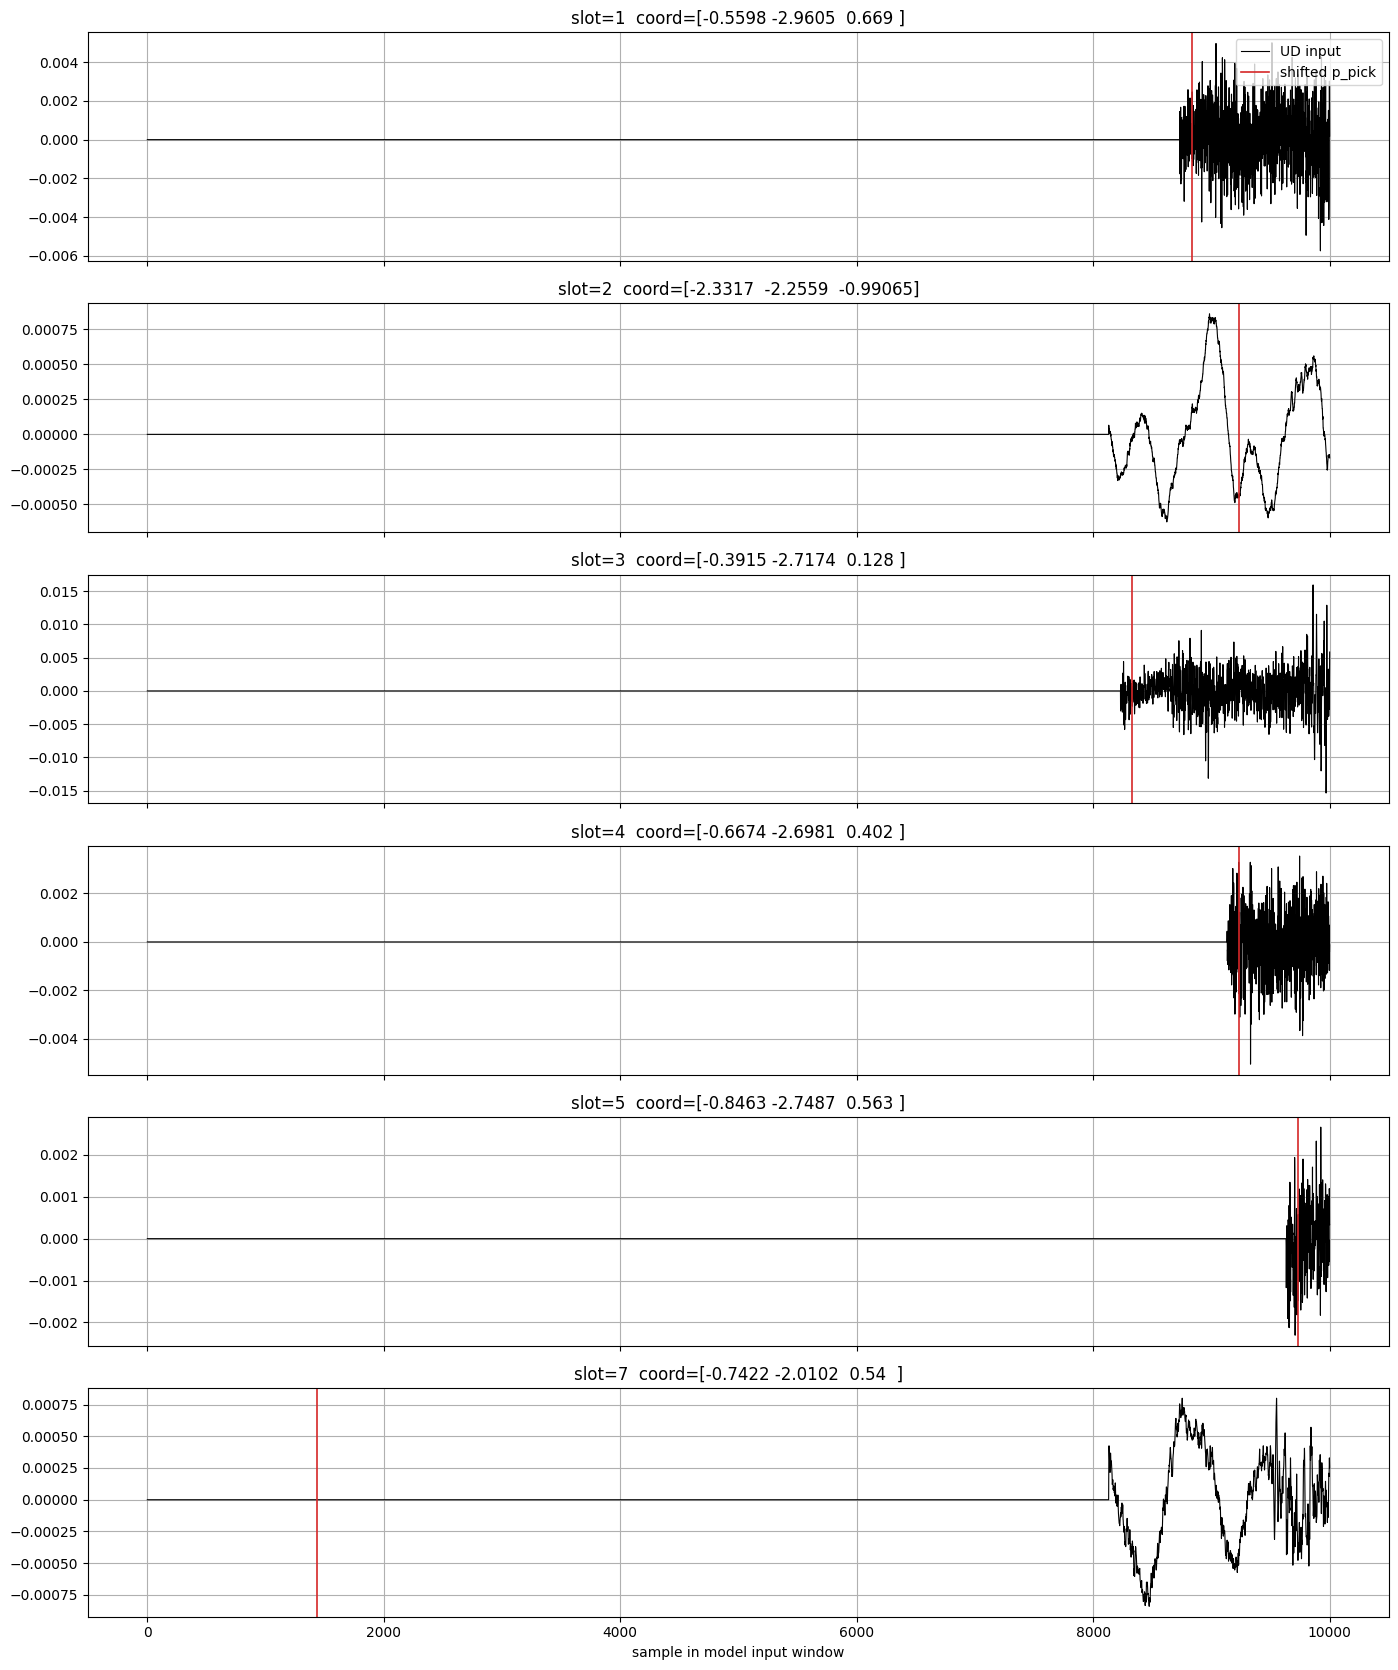

In [25]:
plot_slots = valid_idx[:min(6, len(valid_idx))]
fig, axes = plt.subplots(len(plot_slots), 1, figsize=(14, 2.8 * max(1, len(plot_slots))), sharex=True)
if len(plot_slots) == 1:
    axes = [axes]

for ax, slot in zip(axes, plot_slots):
    ax.plot(wave_in[slot, 2], lw=0.8, color='black', label='UD input')
    ax.axvline(p_pick_shifted[slot], color='tab:red', lw=1.2, label='shifted p_pick')
    ax.set_title(f'slot={slot}  coord={coords_in[slot]}')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], labels[:2], loc='upper right')
axes[-1].set_xlabel('sample in model input window')
plt.tight_layout()
plt.show()
plt.close('all')

In [15]:
# 如果配置启用了 PGA target，这里查看目标点和标签
if len(inputs) >= 5:
    pga_targets = inputs[3].numpy()
    pga_valid = inputs[4].numpy().astype(bool)
    pga_labels = outputs[-1].numpy().reshape(-1)
    display(pd.DataFrame({
        'valid': pga_valid,
        'pga_label': pga_labels,
        'lat': pga_targets[:, 0],
        'lon': pga_targets[:, 1],
        'depth_or_height': pga_targets[:, 2],
    }).head(20))
else:
    print('当前配置没有 PGA targets。')

,valid,pga_label,lat,lon,depth_or_height
0,True,-1.514553,0.4410,-1.1575,0.021
1,True,0.260954,0.3458,-2.7564,0.019
2,True,-1.615897,-0.2179,-1.0305,0.494
3,True,-0.575256,-0.1341,-3.0250,0.004
4,True,-1.431425,-0.6674,-2.6981,0.402
5,True,-1.776809,-1.0676,-2.4050,1.150
6,True,-2.118839,1.1327,-0.5711,0.006
7,True,-2.667683,-1.3848,-2.1203,0.608
8,True,-1.594707,-0.1886,-1.2151,0.985
9,True,-1.207779,-0.6024,-3.5591,0.003
